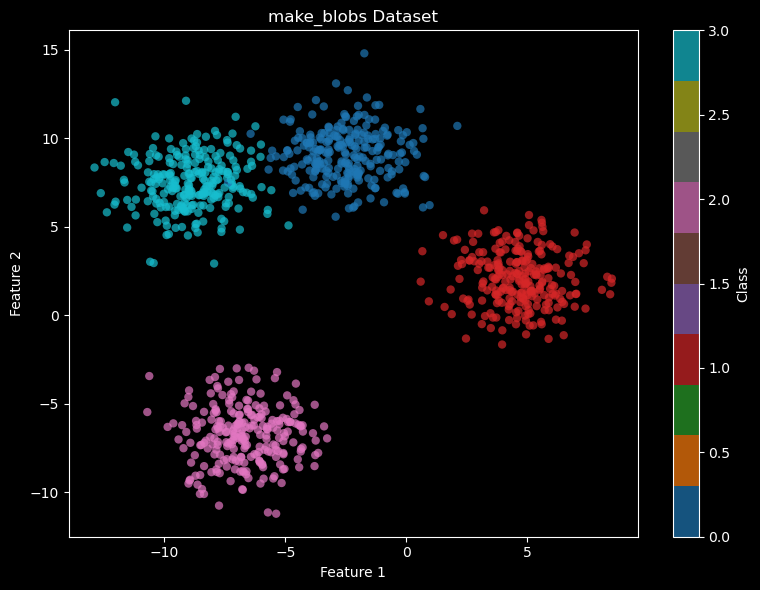

Starting GridSearchCV...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Done.
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best F1 Macro Score: 0.9910


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

plt.style.use('dark_background')

# Generate dataset
X, y = make_blobs(n_samples=1000, centers=4, cluster_std=1.5, random_state=42)

# Plot dataset
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10', alpha=0.7, edgecolors='none')
plt.colorbar(scatter, label='Class')
plt.title("make_blobs Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

# Define parameter grid for DecisionTreeClassifier
param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

# Define the model
dt_model = DecisionTreeClassifier(random_state=42)

# Define cross-validation strategy
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scorer
f1_macro = make_scorer(f1_score, average='macro')

# Define GridSearchCV
grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=skf,
    scoring=f1_macro,
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearchCV...")
grid_search.fit(X, y)
print("Done.")

print("Best Parameters:", grid_search.best_params_)
print(f"Best F1 Macro Score: {grid_search.best_score_:.4f}")
